# **Loading the Dataset**

In [1]:
pip install pandas


In [2]:
# Import necessary library
import pandas as pd

df = pd.read_csv('/content/House Price India.csv')

# Display the first few rows of the dataset to understand its structure
print(df.head())


           id   Date  number of bedrooms  number of bathrooms  living area  \
0  6762810635  42491                   4                 2.50         2920   
1  6762810998  42491                   5                 2.75         2910   
2  6762812605  42491                   4                 2.50         3310   
3  6762812919  42491                   3                 2.00         2710   
4  6762813105  42491                   3                 2.50         2600   

   lot area  number of floors  waterfront present  number of views  \
0      4000               1.5                   0                0   
1      9480               1.5                   0                0   
2     42998               2.0                   0                0   
3      4500               1.5                   0                0   
4      4750               1.0                   0                0   

   condition of the house  ...  Built Year  Renovation Year  Postal Code  \
0                       5  ...    

# **Data Preprocessing**

In [3]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Print the number of missing values for each column
print(missing_values)


id                                       0
Date                                     0
number of bedrooms                       0
number of bathrooms                      0
living area                              0
lot area                                 0
number of floors                         0
waterfront present                       0
number of views                          0
condition of the house                   0
grade of the house                       0
Area of the house(excluding basement)    0
Area of the basement                     0
Built Year                               0
Renovation Year                          0
Postal Code                              0
Lattitude                                0
Longitude                                0
living_area_renov                        0
lot_area_renov                           0
Number of schools nearby                 0
Distance from the airport                0
Price                                    0
dtype: int6

**Convert Date Format**

In [4]:
# Convert 'Date' from numeric (Excel date format) to datetime
df['Date'] = pd.to_datetime(df['Date'] - 2, unit='D', origin=pd.Timestamp('1900-01-01'))


**Add New Features**
*   Age of the House: This will calculate the age of the house based on the year built and the current year (assuming analysis in 2023).
*   Was the House Renovated?: This will check if there has been any renovation done (i.e., 'Renovation Year' is not 0).



In [5]:
# Add 'Age of House' which calculates how old the house is from the current year
df['Age of House'] = 2023 - df['Built Year']

# Add 'Is Renovated' which checks if the renovation year is not 0
df['Is Renovated'] = df['Renovation Year'].apply(lambda x: 1 if x > 0 else 0)

In [6]:
# Display the first few rows to see the new changes
print(df.head())


           id       Date  number of bedrooms  number of bathrooms  \
0  6762810635 2016-05-01                   4                 2.50   
1  6762810998 2016-05-01                   5                 2.75   
2  6762812605 2016-05-01                   4                 2.50   
3  6762812919 2016-05-01                   3                 2.00   
4  6762813105 2016-05-01                   3                 2.50   

   living area  lot area  number of floors  waterfront present  \
0         2920      4000               1.5                   0   
1         2910      9480               1.5                   0   
2         3310     42998               2.0                   0   
3         2710      4500               1.5                   0   
4         2600      4750               1.0                   0   

   number of views  condition of the house  ...  Postal Code  Lattitude  \
0                0                       5  ...       122004    52.8878   
1                0                    

# **Exploratory Data Analysis (EDA)**

**Histogram for Property Prices**

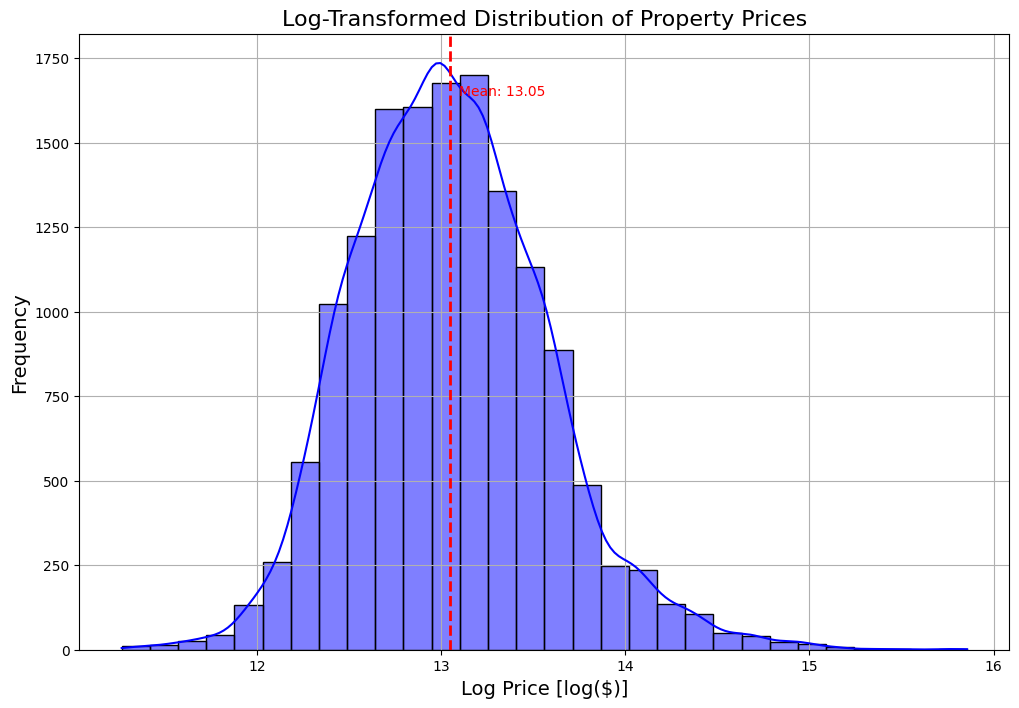

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming you've already loaded the dataframe and added a 'Log Price' column
# df['Log Price'] = np.log1p(df['Price'])

# Enhanced plotting
plt.figure(figsize=(12, 8))
ax = sns.histplot(df['Log Price'], kde=True, bins=30, color='blue', edgecolor='black')
plt.title('Log-Transformed Distribution of Property Prices', fontsize=16)
plt.xlabel('Log Price [log($)]', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True)

# Adding a vertical line for the mean
mean_price = df['Log Price'].mean()
plt.axvline(mean_price, color='red', linestyle='--', linewidth=2)
plt.text(mean_price+0.05, plt.ylim()[1]*0.9, f'Mean: {mean_price:.2f}', color = 'red')

plt.show()


The histogram displayed represents the log-transformed distribution of property prices, with a notably normal distribution centered around a mean of approximately 13.05. This transformation addresses skewness in the original data, making the distribution more symmetrical and better suited for statistical analysis and predictive modeling. The red dashed line marks the mean, emphasizing the central tendency of the data, which is essential for understanding typical property values on a logarithmic scale. This normalized distribution is crucial for applying various machine learning algorithms that assume data normality, thereby enhancing the robustness and accuracy of predictive models.

**Box Plot for Living Area**

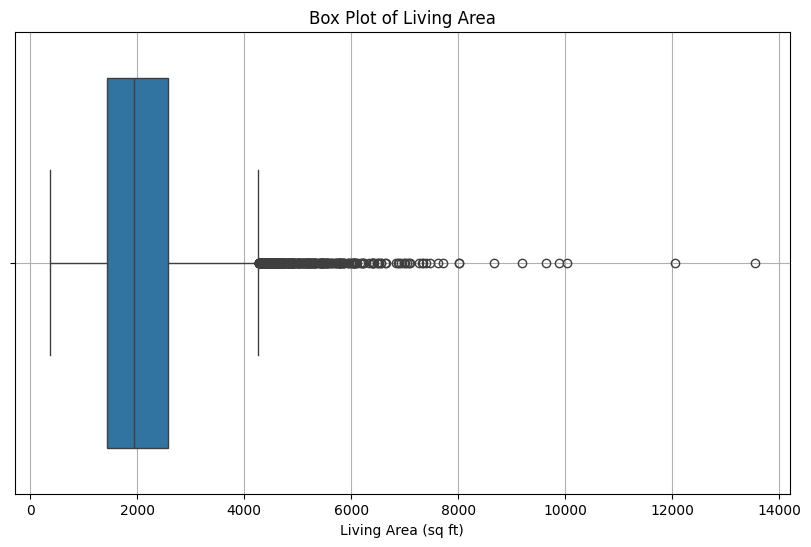

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['living area'])
plt.title('Box Plot of Living Area')
plt.xlabel('Living Area (sq ft)')
plt.grid(True)
plt.show()


The box plot visualizes the distribution of the living area (in square feet) of properties. This type of plot is particularly useful for identifying the spread and central values of the data, as well as spotting outliers. From the plot, we see that the median living area is considerably less than 4000 sq ft, which is represented by the line inside the box. The interquartile range (the box) suggests that the middle 50% of the data is relatively compact, indicating consistency in property sizes. However, there are numerous outliers on the higher end, indicating some properties with exceptionally large living areas, extending beyond 10,000 sq ft, which are far from the norm. These outliers could be indicative of luxury or unusually large properties within the dataset.


**Correlation Heatmap**

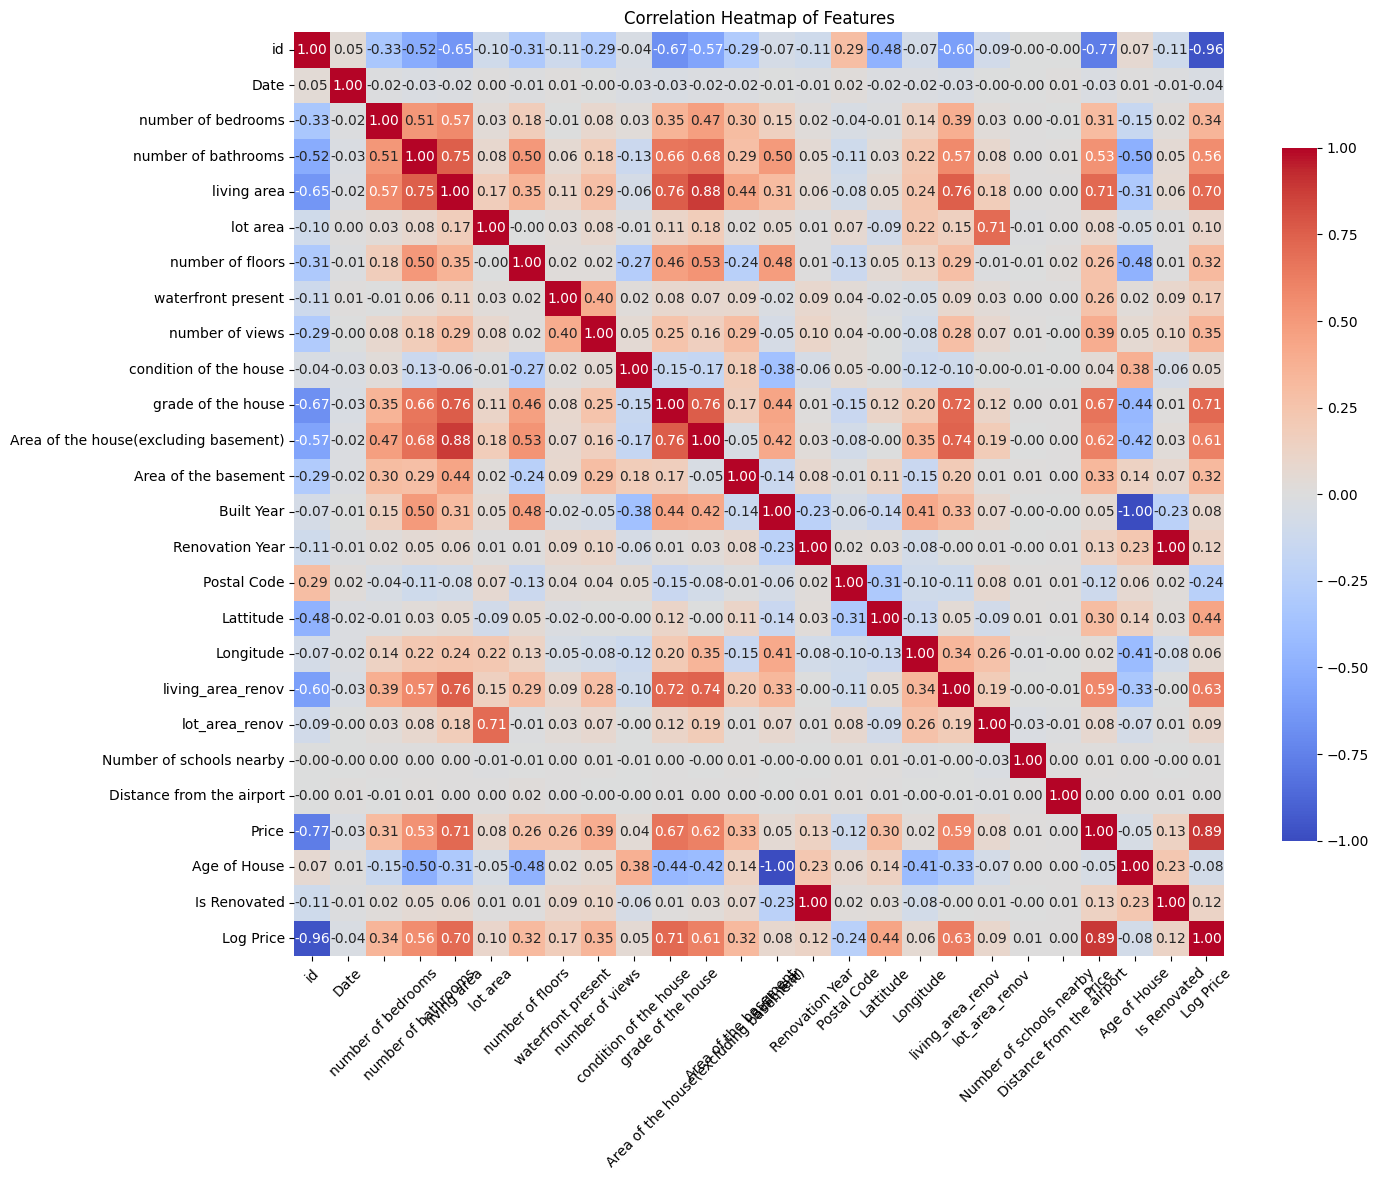

In [14]:
plt.figure(figsize=(15, 12))
# Using a diverging palette for better visual distinction of positive and negative
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'shrink': .75})
plt.title('Correlation Heatmap of Features')
# Rotating the labels for better legibility
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


 This is a correlation heatmap of features related to property prices, showcasing the degree to which variables are linearly related to each other. Each cell in the heatmap is color-coded, with shades of red indicating positive correlations and shades of blue denoting negative correlations. Values close to 1 or -1 signify strong positive or negative correlations, respectively, whereas values near 0 indicate weak or no linear correlation. This visualization is crucial for identifying relationships between variables, such as the strong positive correlation between the number of bathrooms and the living area, which can help in feature selection and understanding underlying patterns in the data for more informed modeling decisions.

# **Model Building and Training**

In [15]:
from sklearn.model_selection import train_test_split

# Assuming 'df' is your DataFrame and 'Log Price' is your target variable
X = df.drop(['Price', 'Log Price', 'id', 'Date'], axis=1)  # Drop non-predictive columns
y = df['Log Price']  # Target variable

# Split the dataset into training and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create a Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Predict on the test set
linear_predictions = linear_model.predict(X_test)

# Calculate metrics
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

print(f'Linear Regression RMSE: {linear_rmse:.3f}')
print(f'Linear Regression R^2: {linear_r2:.3f}')


Linear Regression RMSE: 0.251
Linear Regression R^2: 0.783


**Root Mean Squared Error (RMSE)**

The RMSE metric is essentially the standard deviation of the residuals or prediction errors. Residuals are a measure of how far from the regression line data points are; RMSE is a measure of how spread out these residuals are. In other words, it tells us how concentrated the data is around the line of best fit.



*   **Observed Value:** The RMSE value for our model is 0.251.
*   **Interpretation:** This value indicates that, on average, our model's predictions deviate from the actual values by 0.251 on the log scale. Since RMSE values are in the same units as the response variable being predicted, a lower RMSE value is better as it indicates a more accurate prediction. In our case, an RMSE of 0.251 suggests that the model is quite accurate in predicting property prices, albeit there's always room for improvement.




**Coefficient of Determination (R²)**

The R² metric provides us with an understanding of the amount of variance in the dependent variable that's explained by the independent variables in the model. It is a statistical measure that highlights the effectiveness of the explanatory variables in predicting our response variable.


*  **Observed Value:** The R² value for our model is 0.783.
*   **Interpretation:** This means that about 78.3% of the variation in property prices can be explained by the variables included in our model. An R² value of 0.783 is quite high, indicating that our model fits the data well and can explain a significant portion of the variability in property prices. However, it also suggests that there may be other factors or variables not included in the model that account for the remaining 21.7% of the variation in property prices.



    
    


In [17]:
from sklearn.ensemble import RandomForestRegressor

# Create a Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
rf_predictions = rf_model.predict(X_test)

# Calculate metrics
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print(f'Random Forest RMSE: {rf_rmse:.3f}')
print(f'Random Forest R^2: {rf_r2:.3f}')


Random Forest RMSE: 0.176
Random Forest R^2: 0.893


**Comparative Analysis**

The comparison between the two models shows that the Random Forest model is significantly more effective at predicting property prices than the Linear Regression model. The lower RMSE and higher R² in the Random Forest model demonstrate its superior capability in handling the non-linearities and complex interactions between features, which are often present in real-world data like property prices.

The Linear Regression model, while useful for understanding the influence of individual predictors in a simplified form, does not capture as much of the variability as the Random Forest. This makes the Random Forest more suitable for applications where precision is critical, such as in investment decisions or policy formulation in urban planning and real estate development.

# **Model Diagnostics**

**Residual Analysis for Random Forest**

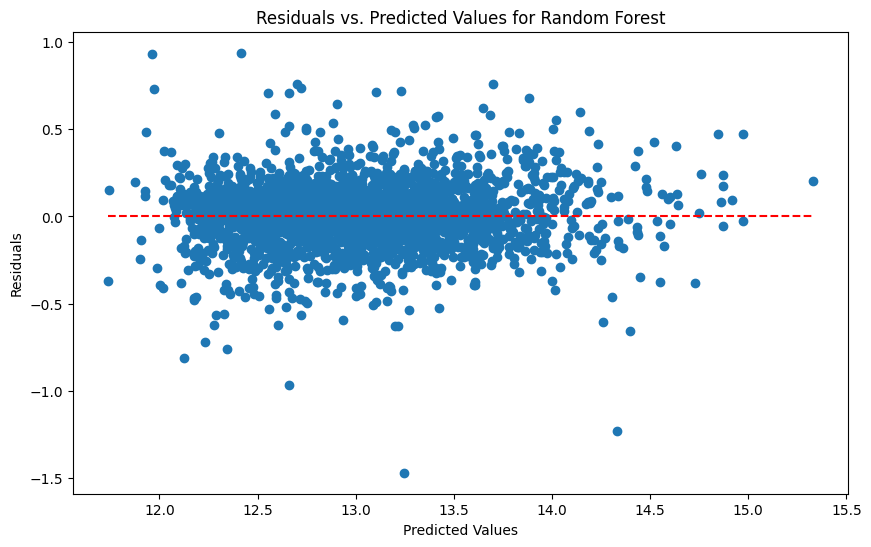

In [18]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - rf_predictions

# Plot residuals
plt.figure(figsize=(10, 6))
plt.scatter(rf_predictions, residuals)
plt.hlines(y=0, xmin=min(rf_predictions), xmax=max(rf_predictions), colors='red', linestyles='--')
plt.title('Residuals vs. Predicted Values for Random Forest')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()


The plot shown is a residual plot for the Random Forest model used in predicting property prices. Residuals, the vertical distances between the actual data points and the predicted values, are plotted against the predicted values. Ideally, residuals should be randomly dispersed around the horizontal axis (red dashed line), indicating that the model's predictions are unbiased at any point. In this plot, the majority of residuals cluster near zero without any apparent patterns or systematic deviations, which suggests good model performance with minor exceptions of a few outliers, particularly for higher predicted values. This visualization is crucial for diagnosing the model by checking for non-random patterns that could indicate issues like heteroscedasticity or model misspecification.


**Feature Importance**

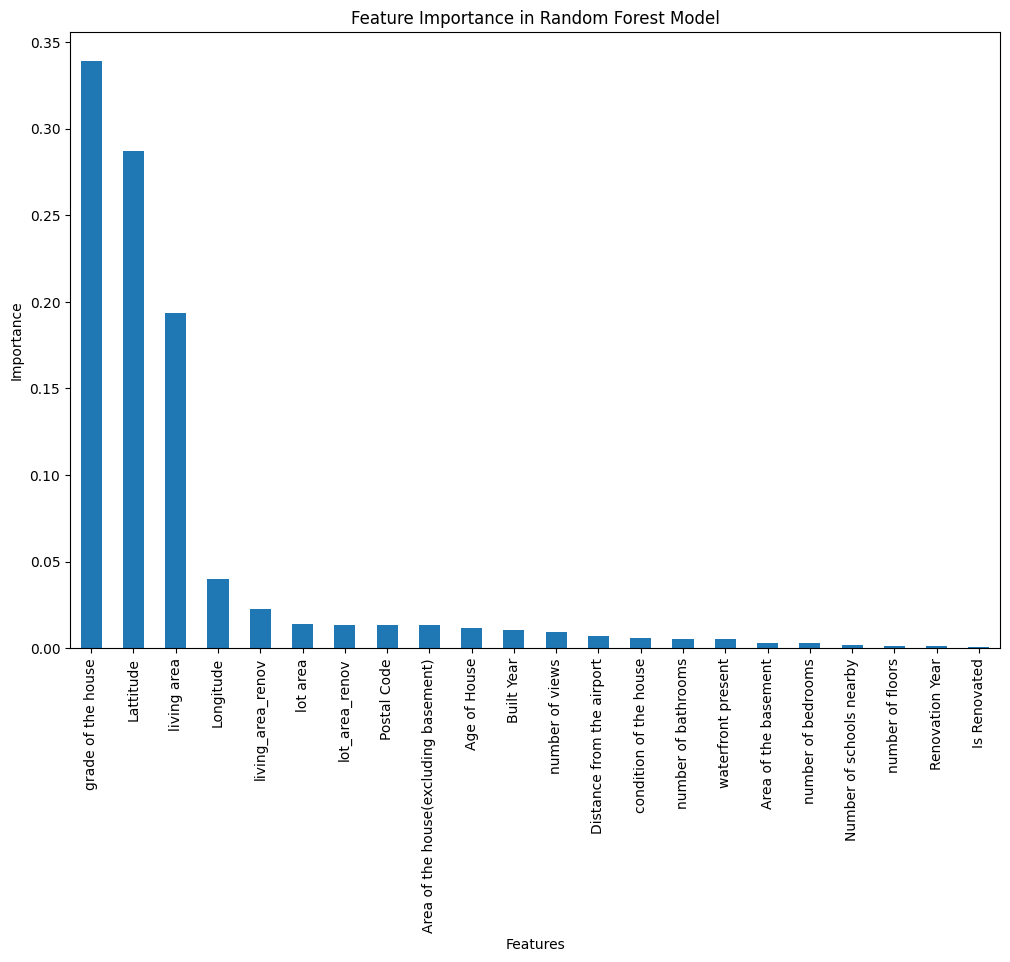

In [19]:
# Extracting feature importance from the Random Forest model
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# Plotting feature importance
plt.figure(figsize=(12, 8))
feature_importances.sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()


The bar chart you provided displays the feature importance derived from a Random Forest model used to predict property prices. Feature importance is a technique that assigns a score to input features based on how useful they are at predicting a target variable.


**Key Observations:**

*   **Grade of the House:** This feature has the highest importance, significantly influencing the model's predictions. It suggests that the quality and amenities of a house play a critical role in determining its price.
*   **Latitude:** The second most important feature, indicating that the property's location, likely related to geographical desirability, strongly affects its price.
*   **Living Area:** Consistently important in real estate valuation, the size of the living space is a key determinant of property price.

This visualization helps in understanding which factors are most predictive of property prices, allowing stakeholders to focus on these aspects when assessing property values or considering improvements. For example, improving the grade or quality of a house could potentially increase its market value more significantly than other factors. Moreover, developers and real estate investors can use this information to prioritize investments in properties located in more desirable latitudes or those with potential for living area expansion.





    
    
    


# **Visualization**

**Histogram of Predicted vs Actual Values**

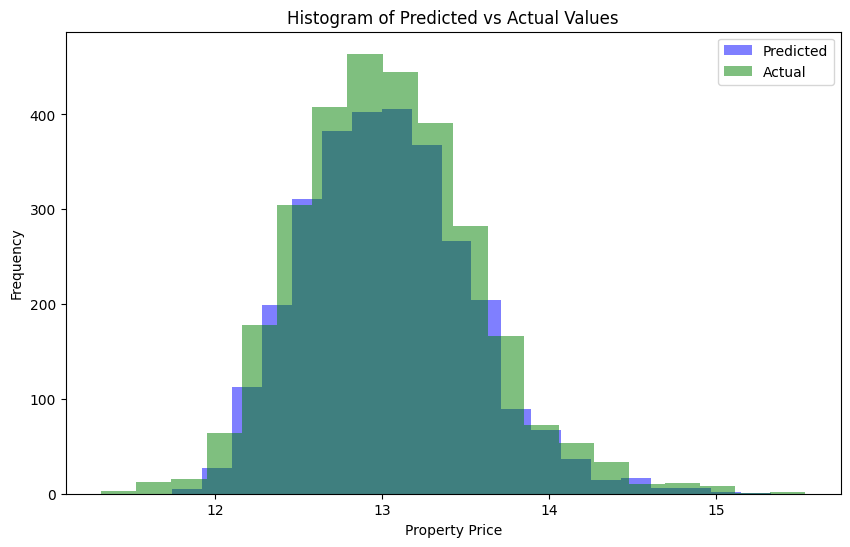

In [28]:
import matplotlib.pyplot as plt

# Assuming 'rf_predictions' are the predictions from your Random Forest model and 'y_test' are the actual values
plt.figure(figsize=(10, 6))
plt.hist(rf_predictions, bins=20, alpha=0.5, label="Predicted", color='blue')
plt.hist(y_test, bins=20, alpha=0.5, label="Actual", color='green')
plt.xlabel('Property Price')
plt.ylabel('Frequency')
plt.title('Histogram of Predicted vs Actual Values')
plt.legend()
plt.show()


**Scatter Plot of Predicted vs Actual Values**

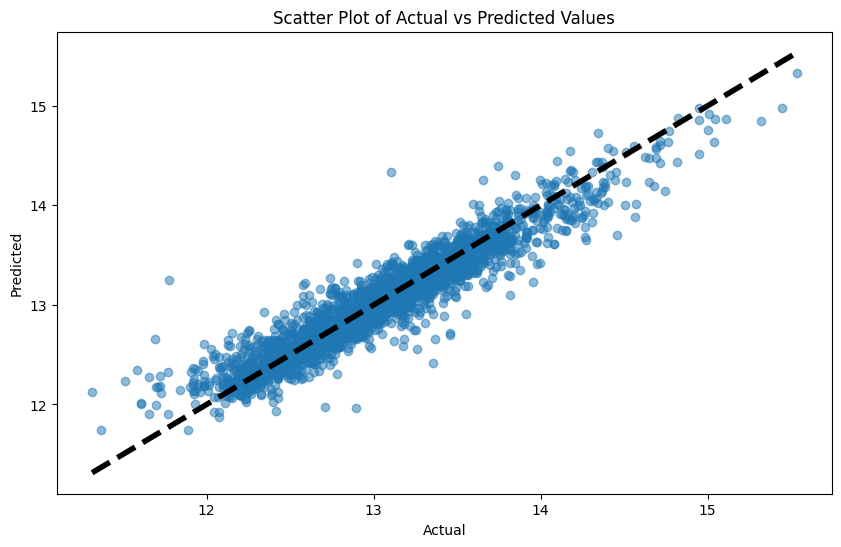

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)  # Line showing perfect predictions
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Scatter Plot of Actual vs Predicted Values')
plt.show()


**Heatmap of Feature Correlations with Residuals**

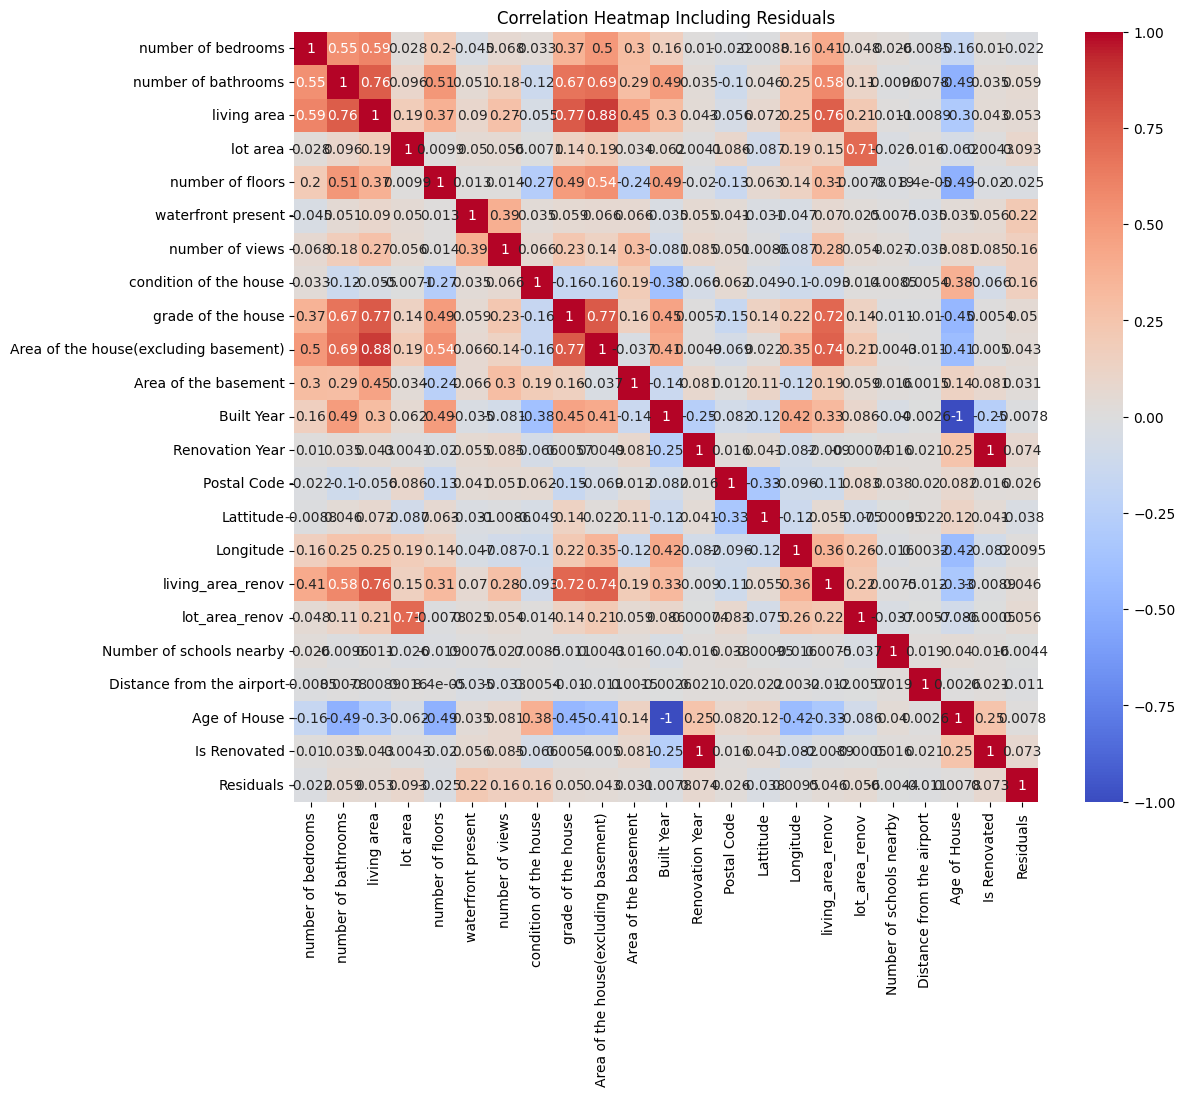

In [32]:
import seaborn as sns
import pandas as pd

# Assuming 'X_test' is your test dataset and 'errors' are your prediction residuals
data = X_test.copy()
data['Residuals'] = errors
correlation_matrix = data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap Including Residuals')
plt.show()
